In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.formula.api import ols
import mplcyberpunk as mpc
import scipy.stats as stats
import pingouin as pg

In [248]:
# apply theme to all plots
plt.style.use("cyberpunk")

# pandas setting to  display all columns 
# pd.set_option('display.max_columns', None)

# Ways of creating a dataframe:
## 1 - A dictionary of list of column values
Here `key` - column name & `val` - list of values for that column

In [249]:
# a dictionary of column : column_values
datadf1 = {"Name": ["Alice", "Bob" , "Charlie","Mike"],
        "Age": [26, 27,29,30],
        "City": ["New York" , "London" , "Paris","Los Angeles"],
        "join_date":["2025-10-01", "2024-09-23" , "2025-06-10" , "2025-01-10"]}

# Loading as a dataframe
df1 = pd.DataFrame(datadf1)

# Converting join_date column to datetime format
df1["join_date"] = pd.to_datetime(df1["join_date"])

print(df1.dtypes)
print(df1)

Name                    str
Age                   int64
City                    str
join_date    datetime64[us]
dtype: object
      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   27       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [250]:
# Extracting only specific part of dates
df1["join_date"].dt.month_name()

0      October
1    September
2         June
3      January
Name: join_date, dtype: str

## Filtering rows / columns using `loc` & `iloc`

In [251]:
# Filtering based on iloc - works similar to lists indexing
df1.iloc[1, 1] = 28
print(df1)

      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   28       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [252]:
# Creating a copy of the dataset
df2 = df1.copy()
df2.set_index("Name", inplace=True)

In [253]:
# filtering using loc - used for named indexes
df2.loc["Bob":"Mike",['Age','join_date']]

,Age,join_date
Name,,
Bob,28,2024-09-23
Charlie,29,2025-06-10
Mike,30,2025-01-10


# Probability revision

In [254]:
df = pd.read_csv('../statistics_in_python/stats_datasets/weightsheights.csv', usecols=["Height in cm" , "Weight in kg"]).round(2)
df.columns = df.columns.str.replace(' ', '_')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Height_in_cm  25000 non-null  float64
 1   Weight_in_kg  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


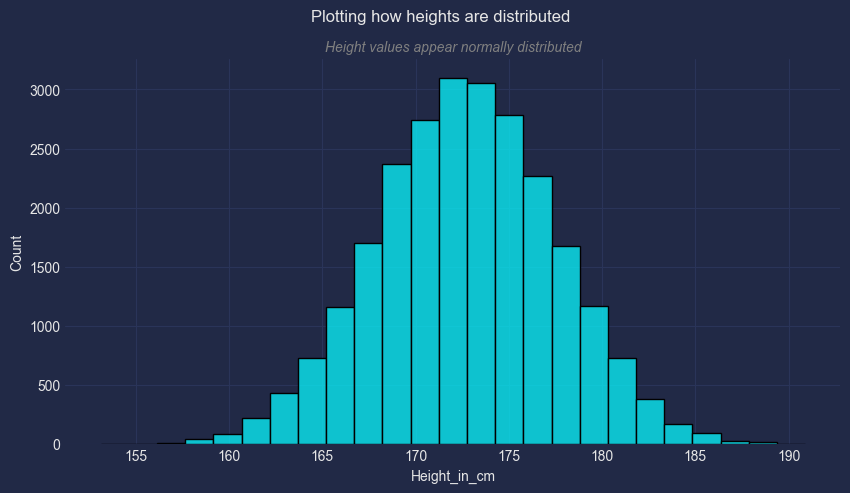

In [255]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()

> Thus its observed that majority of heights are between 168-176 cm, quantiles will give better idea

In [256]:
the_quantiles = [0.25, 0.5 , 0.75, 1]

for each in the_quantiles: 
    print(f"Heights in {each}-ile : {np.quantile(df["Height_in_cm"],each)}")    


Heights in 0.25-ile : 169.43
Heights in 0.5-ile : 172.71
Heights in 0.75-ile : 175.95
Heights in 1-ile : 190.89


Text(0.5, 1.0, 'Overview of statistics using boxplot')

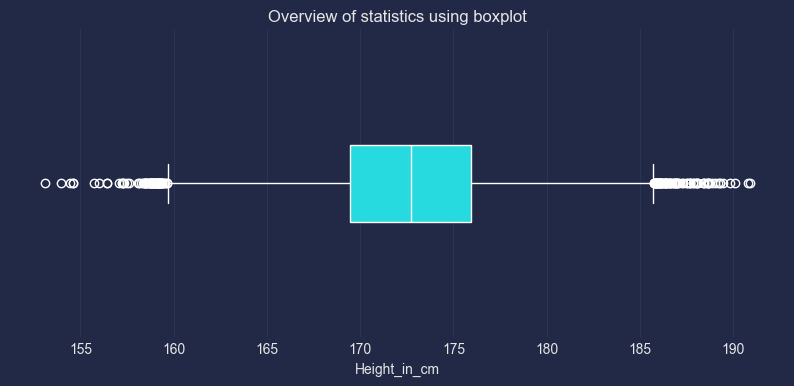

In [257]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Height_in_cm", width=0.25, flierprops={"markeredgecolor":"white"},linecolor='white')
plt.title("Overview of statistics using boxplot")

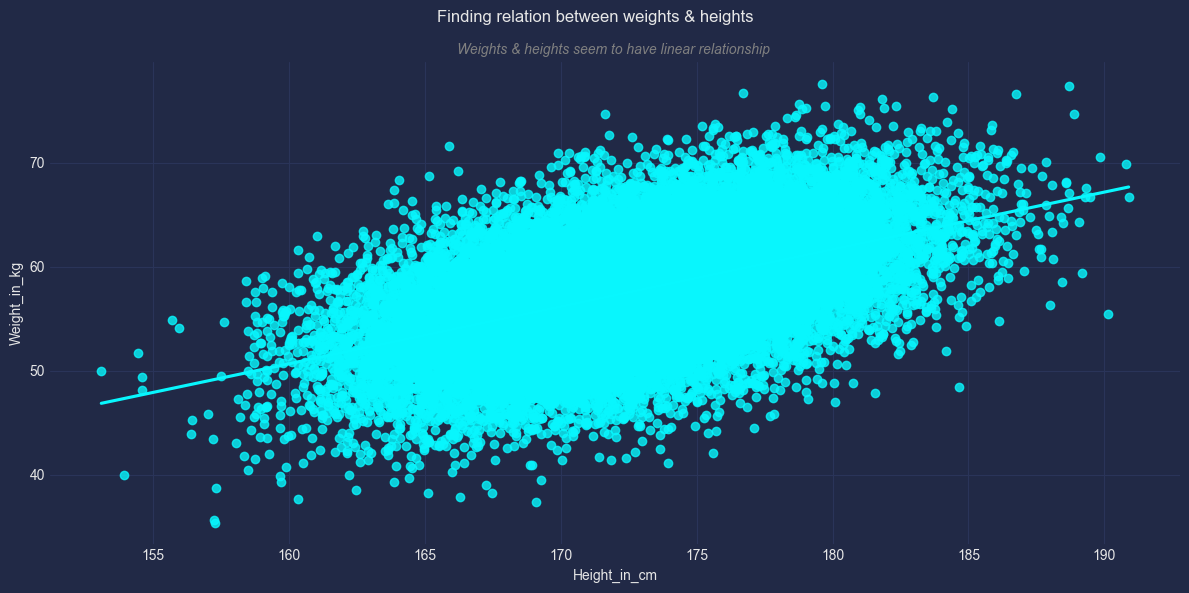

In [258]:
# Finding relation between weights & heights
plt.figure(figsize=(12,6))
sns.regplot(data=df , x= 'Height_in_cm' , y='Weight_in_kg', ci=None)
plt.suptitle('Finding relation between weights & heights')
plt.title("Weights & heights seem to have linear relationship " , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.tight_layout()
plt.show()


## Determining the fit  

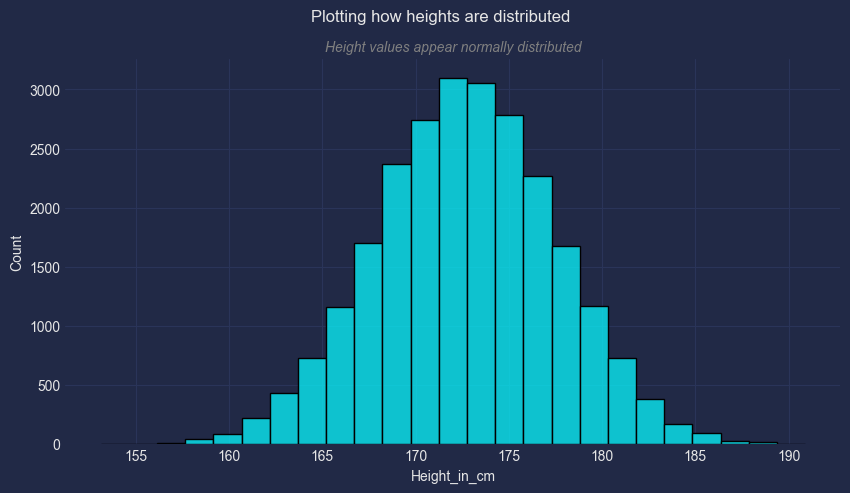

In [259]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Determining the fit  

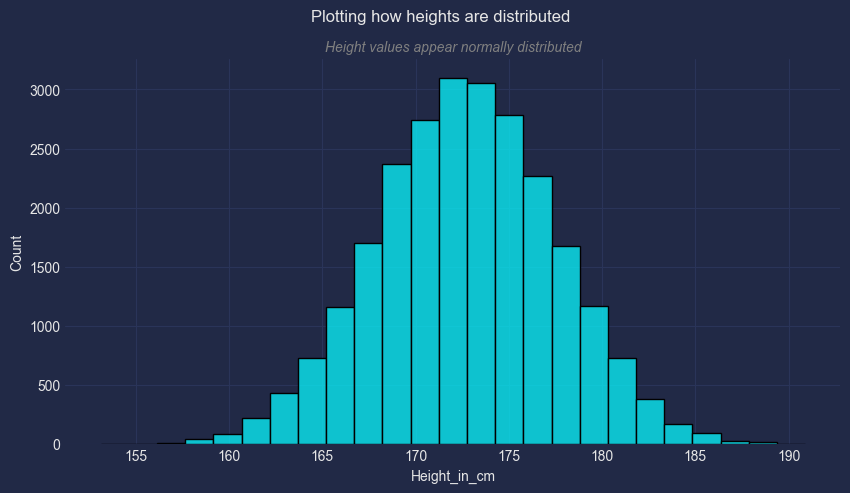

In [260]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Finding likelihood
**Q: What is the probability% that a person's height from the dataset < 172cm?**

In [261]:
height_mean = df.describe().loc["mean", "Height_in_cm"]
height_stdev  = df.describe().loc["std", "Height_in_cm"]

In [262]:
norm.cdf(172, loc= height_mean ,scale= height_stdev)

np.float64(0.44218866026199904)

>So there's a 44% chance that a person's height, selected randomly from the dataset, is less than 172cm .


**Q: What is the probability% that a person's height from the dataset > 178cm?**

In [263]:
1 - norm.cdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.1363767033562957)

>So there's a 13.6% chance that a person's height, selected randomly from the dataset, is more than than 178cm .

**Q: What is the probability% that a person's height from the dataset is exactly 178cm?**

In [264]:
norm.pdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.045263032907543306)

>So there's a 4.5% chance that a person's height, selected randomly from the dataset, is exactly 178cm .

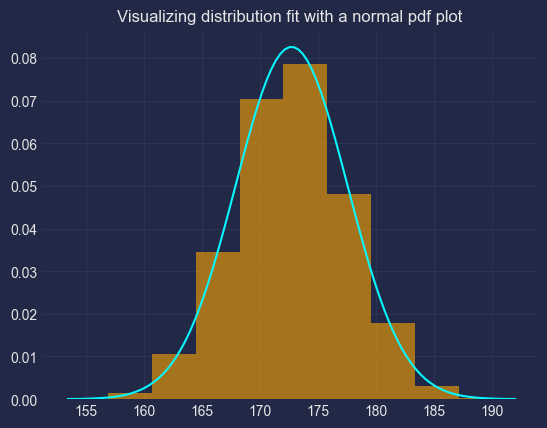

In [265]:
import scipy.stats

mu=height_mean
sigma=height_stdev

# calculating 100 evenly spaced intervals in a range
# of +/- 4 standard Deviations above / below the mean
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.hist(df["Height_in_cm"] , density=True, alpha=0.6, color='orange', label='Actual Data')
plt.title("Visualizing distribution fit with a normal pdf plot")
plt.plot(x,y)
plt.show()

If you were to run that same code with $n=500$:

- At $n=50$: Your histogram might look a bit "jagged," and the PDF curve is relatively wide.
- At $n=500$: The histogram bars would align almost perfectly with the PDF curve, and the entire structure would be much thinner and taller.

# Linear Regression
For the given `weightsheights.csv` dataset,consider:

- `height_in_cm` is explanatory (independent) variable

- `weight_in_kg` is response (dependent) variable

In [266]:
model = ols("Weight_in_kg ~ Height_in_cm", data=df).fit()
model.params

Intercept      -37.454069
Height_in_cm     0.550637
dtype: float64

### Understanding Model objects
`fitted_vals` - Fitted values:  The models predictions of y-values (dependent variable) for each observation on the training data.<br>
The `fitted_vals` help evaluate how well a predicted model fits the training dats

`resid` - The difference between the actual y-value in the  training dataset AND the fitted value.<br>
A model is a good fit if the residuals are - generally small; are centered around zero & have no obvious pattern

In [267]:
fitted_vals = model.fittedvalues

df.assign(fitted_vals = fitted_vals)

,Height_in_cm,Weight_in_kg,fitted_vals
0,167.09,51.25,54.551931
1,181.65,61.91,62.569211
2,176.27,69.41,59.606782
3,173.27,64.56,57.954870
4,172.18,65.45,57.354675
...,...,...,...
24995,176.54,53.54,59.755454
24996,163.95,54.52,52.822929
24997,164.33,53.64,53.032171
24998,171.52,60.00,56.991254


In [269]:
model.resid

0       -3.301931
1       -0.659211
2        9.803218
3        6.605130
4        8.095325
           ...   
24995   -6.215454
24996    1.697071
24997    0.607829
24998    3.008746
24999   -2.239940
Length: 25000, dtype: float64

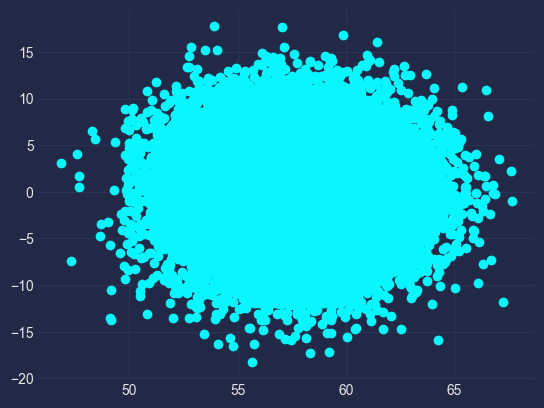

In [270]:
plt.scatter(model.fittedvalues, model.resid)
plt.show()

Above plots confirms that model is likely a good fit because:
- Residuals are centered around 0
- are randomly scattered (no patterns)
- spread of residuals is roughly constant across fitted values

Along with residuals plot, we should look at the comprehensive model summary presented by the `summary` method

In [275]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weight_in_kg   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     8460.
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:20:20   Log-Likelihood:                -73471.
No. Observations:               25000   AIC:                         1.469e+05
Df Residuals:                   24998   BIC:                         1.470e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -37.4541      1.034    -36.212      0.000     -39.481     -35.427
Height_in_cm     0.5506      0.006     91.980      0.000       0.539       0.562
==============================================================================
Omnibus:                        1.024   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.599   Jarque-Bera (JB):                1.029
Skew:                          -0.016   Prob(JB):                        0.598
Kurtosis:                       2.996   Cond. No.                     6.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

`R-square:` _How much variation does the model explain?_ . So, the independent variable (height_in_cm) only explains 25.3% of the variation in dependent variable(weight).
> This tells us that, although a statistically significant  relationship exists between independent variable (height) & the dependent variable(weight), its not a particularly strong predictive model.

So there are other factors influencing the variation of weight values. This makes sensse, as the weight variation cannot be attributed to height alone -- there are other factors like gender/ age/ muscle mass/ genetics etc.

`Omnibus / prof-omnibus`: both >0.05 -- residuals appear approximately normal

`P >|t|:` _P-value associated with t-statistic_. A value $< 0.05$ suggests strong evidence against the null hypothesis, which would be: $H_0: \text{Height has no effect on Weight}$ ; &nbsp;&nbsp;   $H_0: \beta_{height}=0$


___
### The linear equation formed is : 

Weight is calculated as: $Weight = (0.55\times Height) - 37.45$

>This means , for every 1cm increase in height, there's a 0.55X increase in the weight.

The positive slop indicates positive correlation.

In [ ]:
# finding min & max values of heights & weight
print(f"Min. height = {df['Height_in_cm'].min()}cms")
print(f"Max. height = {df['Height_in_cm'].max()}cms")
print("----------------------")
print(f"Min. weight = {df['Weight_in_kg'].min()}kg")
print(f"Max. weight = {df['Weight_in_kg'].max()}kg")

Min. height = 153.11cms
Max. height = 190.89cms
----------------------
Min. weight = 35.39kg
Max. weight = 77.53kg


In [ ]:
# making an interpolation -- 170cms is within the height range
model.predict({"Height_in_cm":170})

0    56.154285
dtype: float64

In [ ]:
# making an extrapolation -- 200cms is outside the height range
model.predict({"Height_in_cm":200})

0    72.673407
dtype: float64

>Interpolation is making predictions within the range of the observed training data. These predictions are generally more reliable because the model has learned from similar observations. 

>Extrapolation is making predictions outside the observed data range. These predictions are less reliable because the model assumes that the learned relationship continues beyond the available data, which may not be true.

______


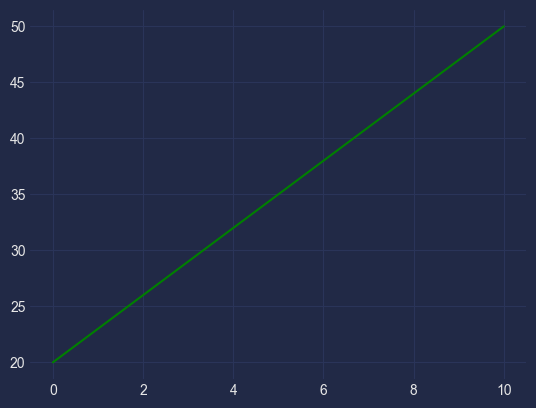

In [ ]:
x1 = np.linspace(0,10,10).round()

y1 = 3*x1 + 20

fig,ax = plt.subplots()
ax.plot(x1,y1, c='green')

plt.show()


In [ ]:
x1


array([ 0.,  1.,  2.,  3.,  4.,  6.,  7.,  8.,  9., 10.])

___
# Revision of Sampling
>The method-2 (numpy + list comprehension) is fastest of the 3 methods listed below & also has minimal memory footprint. 

As for the other two, method-1(`for` loop) is simplest to understand.

In [ ]:
# np.random.seed(2022)
# consider a normally-distributed dataset 
normaldf = pd.DataFrame({"val":np.round(np.random.normal(10,3.0,size=5000),2)})

### Method-1 : using `for` loop 
_using `for` loop  +  (`range` , `sample` & `mean`)  method_. 

This method is simplest to understand but compute time becomes longer as no. of samples / individual sample size grows.

**Output of below code:** each value represents a mean of one bootstrapped sample. So `bootstrapped_means` represents 1000 such means of bootstrapped samples


In [ ]:
# taking bootstrapped samples
bootstrapped_means = []
for i in range(1000):
    # NOTE:size of bootstrapped sample is same as population
    bootstrapped_sample = normaldf.sample(frac=1, replace=True)
    bootstrapped_means.append(bootstrapped_sample["val"].mean())

print(len(bootstrapped_means))
print(bootstrapped_means[0:4])

1000
[np.float64(10.087356), np.float64(10.047051999999999), np.float64(10.091922), np.float64(10.112378)]


In [ ]:
# taking bootstrapped sample means of heights
btstrp_height = []
for i in range(1000):
    btstrp_heightsample = df.sample(frac=1, replace=True)
    btstrp_height.append(btstrp_heightsample["Height_in_cm"].mean())

print(len(btstrp_height))
print(btstrp_height[0:4])

1000
[np.float64(172.7074264), np.float64(172.70295280000002), np.float64(172.70425640000002), np.float64(172.7119232)]


## Method-2 : numpy conversion + list comprehension
**Code output:** is exact same as the above bootstrapping process, but its a _faster & compressed way that uses NumPy & a list comprehension_ instead of a standard `for` loop.

In [ ]:
# converting the concerned column into a numpy array
heights_numpy = df['Height_in_cm'].to_numpy()
# perform sampling with replacement for 1000 times
heights_btstrpmean = [heights_numpy[np.random.randint(0,len(heights_numpy), len(heights_numpy))].mean().round(3) 
                      for _ in range(1000)]

print(f"dtype of heights_numpy : {type(heights_numpy)}")
print(f"dtype of heights_btrspmean : {type(heights_btstrpmean)}")
print(f"length of heights_btrspmean : {len(heights_btstrpmean)}")
print(f"heights_btrspmeans : {heights_btstrpmean[0:4]}")

dtype of heights_numpy : <class 'numpy.ndarray'>
dtype of heights_btrspmean : <class 'list'>
length of heights_btrspmean : 1000
heights_btrspmeans : [np.float64(172.702), np.float64(172.65), np.float64(172.695), np.float64(172.691)]


In [ ]:
# this portion gives mean of one sample set (sampled with replacement)
heights_numpy[np.random.randint(0,len(heights_numpy),len(heights_numpy))].mean()

np.float64(172.69952239999998)

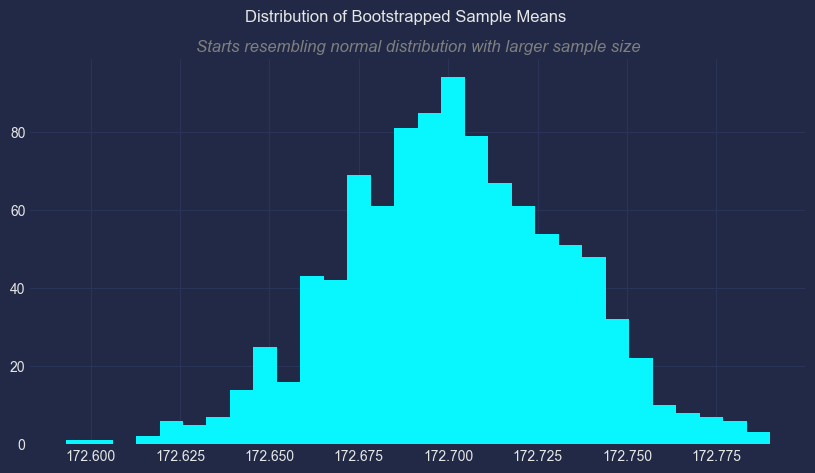

In [ ]:
# plotting the distribution of the bootstrapped sample means
plt.figure(figsize=(10,5))
plt.hist(heights_btstrpmean, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means")
plt.show()

>Proof that , as sampling size increases, the mean of all sampling mean approaches to the true population mean. (Law of large numbers) 

## Method-3 : using `scipy.stats` library's `bootstrap` module
Instead of building manual loops or index selectors, this method outsources the entire statistical process to a heavily optimized scientific library.

The scipy.stats library's `bootstrap` module contains the following params:
- `data` : df column to be sampled, it must be **passed as a Python tuple** of array-like objects
- `statistic` : tells SciPy exactly what metric you want to calculate for every single bootstrap sample (could be `np.mean` ,`np.median` etc.)
- `n_resamples` : number of bootstrapped samples to generate (default is 1000)
- `method` : the math formula to calculate the lower &  upper bounds of  confidence interval from the generated distribution.

**Output of below code:** is a `BootstrapResult` object that contains the confidence interval for the mean of the `height_in_cm` column, calculated from the bootstrapped samples. The confidence interval is typically represented as a tuple with lower and upper bounds.

In [ ]:
# importing bootstrap module from scipy.stats
from scipy.stats import bootstrap
# converting concerned column into numpy array & tuple
data = (df['Height_in_cm'].to_numpy(), )
# create scipy.stats bootstrapped object
res = bootstrap(data= data, statistic=np.mean, n_resamples= 1000, method='percentile')
print(type(res))
# accessing the bootstrapped distribution
btsrp_samplemeans = res.bootstrap_distribution
print(type(btsrp_samplemeans))

<class 'scipy.stats._resampling.BootstrapResult'>
<class 'numpy.ndarray'>


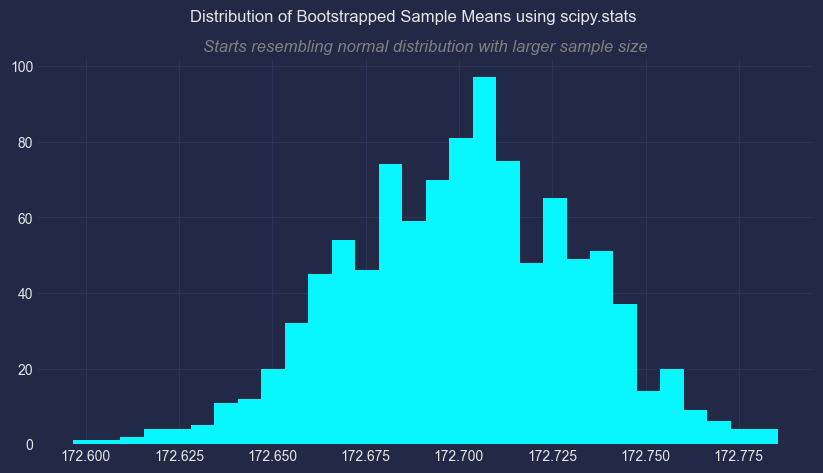

In [ ]:
# plotting the btsrp distribution
plt.figure(figsize=(10,5))
plt.hist(btsrp_samplemeans, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means using scipy.stats")
plt.show()

# Use cases for Hypothesis testing 
>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

>Its a statistical method that helps to determine if the data from sample provides enough evidence to support a specific claim about the larger population. 

A hypothesis test usually consists of 4 parts:
1. **The competing hypotheses** 

    a. **Null hypothesis (H0)**: This is the default assumption or claim that there is no effect or difference. It represents the status quo or a statement of no change.

    b **Alternative hypothesis (H1)**: This is the statement that contradicts the null
2. **Test-statistic**: Its a single numerical value calculated from sample data (z-score, t-score , f-statistic etc.) that measures how closely your observed data aligns with the null hypothesis.
3. **Significance value $(\alpha)$**: Its a pre-determined threshold for proof that's decided before looking at the data. Represents risk being taken of being wrong (Type I error / False positive - i.e. rejecting $H_0$ when it is actually true)

4. **The p-value**: the probability of observing your data, or something more extreme, under the assumption that $H_0$ is true. p-value is compared to the significance level $\alpha$ to decide whether to reject (p-value $\le \alpha$)  or fail to reject (p-value $> \alpha$) the null hypothesis.

### Errors in decision-making
1. **Type I Error /False positive ($\alpha$):** You reject the null hypothesis when it was actually true. (e.g., Convicting an innocent person, or concluding a drug works when it actually doesn't)

2. **Type II Error / False Negative ($\beta$):** You fail to reject the null hypothesis when it was actually false. (e.g., Letting a guilty person go free, or missing a breakthrough medical treatment because your sample size was too small).

## Decision making map for Hypothesis tests


In [ ]:
# loading stckoverflow datasets
stackoverflowdf = pd.read_feather('./datasets/stack_overflow.feather')
print(stackoverflowdf.shape)

# loading the shipments dataset
shipments_df = pd.read_feather('./datasets/late_shipments.feather')
print(shipments_df.shape)

# loading HR dataset
ibmhr_df = pd.read_csv('./datasets/UseCase-HR-Employee-Attrition.csv')
print(ibmhr_df.shape)

(2261, 63)
(1000, 27)
(1470, 35)


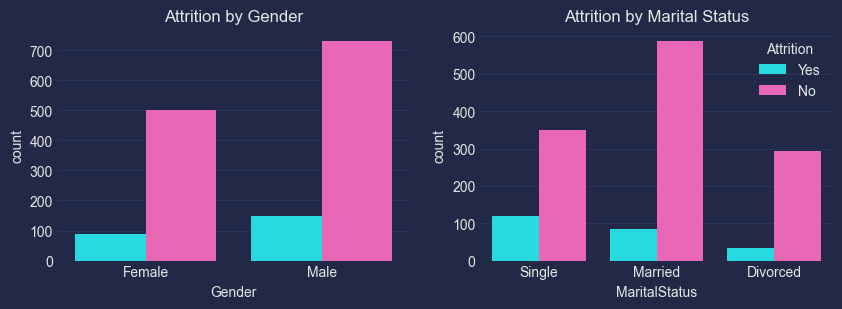

In [ ]:
# conduting basic EDA on the HR dataset
# ibmhr_df.head()
# ibmhr_df.describe()

# #finding if any columns have missing/ NaN  
# ibmhr_df.isnull().sum()

# plotting proportions by gender & marital status
fig,axes = plt.subplots(1,2, figsize=(10,3))
sns.countplot(data=ibmhr_df, x='Gender', hue='Attrition', legend=False, ax=axes[0])
axes[0].set_title("Attrition by Gender")

sns.countplot(data=ibmhr_df, x='MaritalStatus', hue='Attrition', ax=axes[1])
axes[1].set_title("Attrition by Marital Status")
plt.show()

In [ ]:
(pd.crosstab(ibmhr_df['Gender'],ibmhr_df['Attrition'], normalize='index')*100).round(2)

Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,82.99,17.01


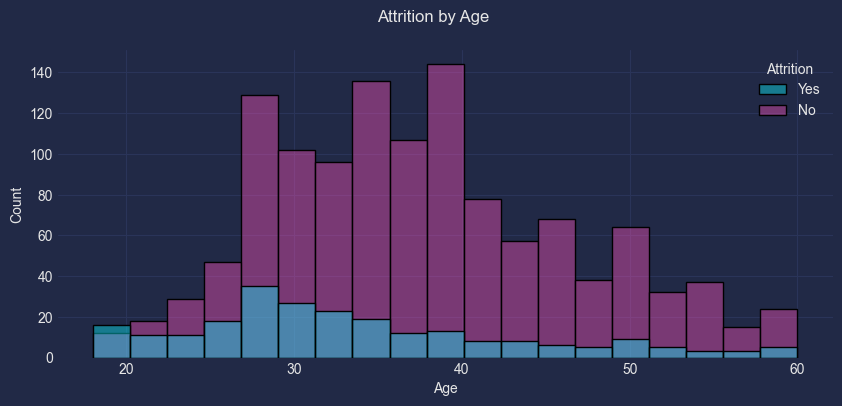

In [ ]:
# plotting attrition by age
plt.figure(figsize=(10,4))
sns.histplot(data=ibmhr_df, x="Age", hue='Attrition',alpha=0.4, multiple='layer')
plt.suptitle("Attrition by Age")
plt.show()

## Classifying hypothesis tests
To make sense of the wide variety of hypothesis tests used in data science and statistics, effectively categorize them based on two factors:
- the type of data you have (Numerical vs. Categorical) and 
- how many groups you are comparing.

### Think of hypothesis testing as a decision tree based on three questions:
- What is the target variable type? - Numeric / binary/ Categorical
- How many groups am I comparing? - One sample to benchmark/ two-sample / 
- What question am I trying to answer? - _Are these groups different?_ OR _does change in X help predict Y?_


In [ ]:
print(ibmhr_df.columns.to_list())
ibmhr_df.head()

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Performing some EDA on the HR dataset :**

In [ ]:
ibmhr_df.iloc[:5,15:20]
print(ibmhr_df['JobRole'].value_counts())
print("\n")
print(ibmhr_df['EducationField'].value_counts())

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


In [ ]:
ibmhr_df.groupby(['JobRole','Attrition'])["MonthlyIncome"].mean().round(2)

JobRole                    Attrition
Healthcare Representative  No            7453.56
                           Yes           8548.22
Human Resources            No            4391.75
                           Yes           3715.75
Laboratory Technician      No            3337.22
                           Yes           2919.26
Manager                    No           17201.48
                           Yes          16797.40
Manufacturing Director     No            7289.93
                           Yes           7365.50
Research Director          No           15947.35
                           Yes          19395.50
Research Scientist         No            3328.12
                           Yes           2780.47
Sales Executive            No            6804.62
                           Yes           7489.00
Sales Representative       No            2798.44
                           Yes           2364.73
Name: MonthlyIncome, dtype: float64

**Lets train focus on Sales Executives**

difference in Avg Monthly Incomes of Sales execs with different backgrounds -- those with marketing degree vs those having technical degree

> Hypothesis: Avg monthly income of sales execs with marketing degree is higher than those with technical degree

> $H_0: \mu_{marketing} = \mu_{technical}$ and <br> 
$H_A : \mu_{marketing} - \mu_{technical} >0$

In [ ]:
# finding diverse education backgrounds of Sales Execs
print(ibmhr_df[ibmhr_df['JobRole']=="Sales Executive"]['EducationField'].value_counts())

# creating a sub-dataframe
ibmsales = ibmhr_df[ibmhr_df['JobRole']=="Sales Executive"].copy()
ibmsales.head()

EducationField
Marketing           122
Life Sciences       107
Medical              65
Technical Degree     19
Other                13
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
27,42,No,Travel_Rarely,691,Sales,8,4,Marketing,1,35,...,4,80,1,10,2,3,9,7,4,2
39,33,No,Travel_Frequently,1141,Sales,1,3,Life Sciences,1,52,...,1,80,2,10,3,3,5,3,1,3
43,27,No,Travel_Frequently,994,Sales,8,3,Life Sciences,1,56,...,4,80,0,9,0,3,9,8,1,7
46,34,No,Non-Travel,1065,Sales,23,4,Marketing,1,60,...,3,80,0,10,2,3,9,5,8,7


## Salary trends for different education backgrounds
Analysing the IBM HR dataset

### 2-sample independent t-test
Comparing the mean of two independent groups (same department , different education backgrounds) via t-tests

In [ ]:
# 2-sample tests - Avg salary of sales execs with marketing vs those with technical degree
grp1 = ibmsales[ibmsales['EducationField']=="Marketing"]['MonthlyIncome']
grp2 = ibmsales[ibmsales['EducationField']=="Technical Degree"]['MonthlyIncome']
se_t_stat, se_p_val = stats.ttest_ind(grp1, grp2, equal_var=False, alternative='greater')
print(f"t-stat= {se_t_stat} \np_val={se_p_val}")

t-stat= -0.7121089088050128 
p_val=0.758281337502016


In [ ]:
# comparing p-val with significance levle of 0.1
se_p_val < 0.1

np.False_

>Thus, we fail to reject the null hypothesis

There isn't enough statistical evidence suggesting Sales execs with a marketing background are earning more than those with technical background.

>This could help address management concerns if one sub-group is being paid more than others.

In [ ]:
# using groupby to discover that actually the inverse is true 
ibmsales.groupby('EducationField')['MonthlyIncome'].mean().round()

EducationField
Life Sciences       6976.0
Marketing           7024.0
Medical             6714.0
Other               5838.0
Technical Degree    7462.0
Name: MonthlyIncome, dtype: float64

## Is MonthlyIncome related to TotalWorkingYears?

## Does MonthlyIncome relate to  JobSat?
- Note that MonthlyIncome  _does not follow normal distribution curve_ even for sub-groups of JobSat levels. Need to look for non-parametric tests

- We're comparing differences in monthly incomes for two independent categories.

- While ANOVA is for comparing normally distributed data stats across multiple categoricals, in this partivular case the **Kruskal-Wallis test needs to be applied**.

First, lets understand the descriptive stats of the columns/ variables involved

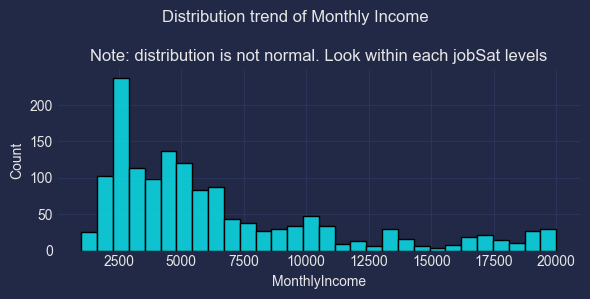

In [ ]:
# Distribution trend of Monthly Income
plt.figure(figsize=(6,3))
sns.histplot(data=ibmhr_df, x='MonthlyIncome', bins=30)
plt.suptitle("Distribution trend of Monthly Income")
plt.title("Note: distribution is not normal. Look within each jobSat levels")
plt.tight_layout()
plt.show()

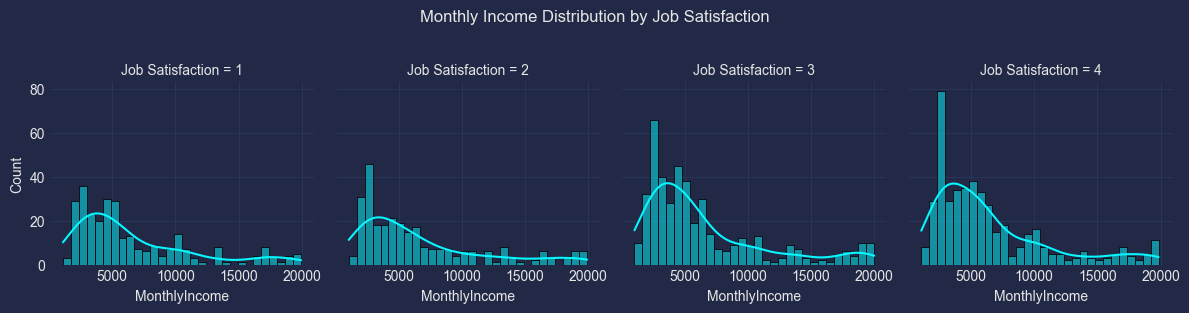

In [ ]:
#plt.figure(figsize=(12,3))
g = sns.FacetGrid(ibmhr_df, col='JobSatisfaction')

g.map_dataframe(sns.histplot, x='MonthlyIncome', bins=30, kde=True)

g.set_titles("Job Satisfaction = {col_name}")
g.figure.suptitle("Monthly Income Distribution by Job Satisfaction", y=1.03)
plt.tight_layout()
plt.show()

Thus we see that monthlyIncome does not follow normal distribution even amongst individual jobSat levels

Now plotting stats for each of the JobSat levels:

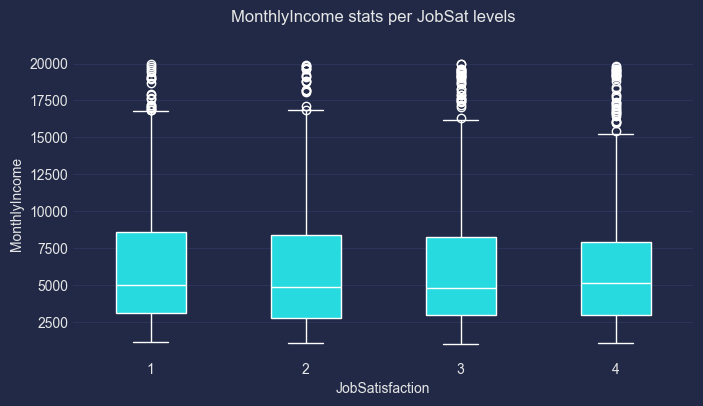

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=ibmhr_df, x= 'JobSatisfaction' , y= 'MonthlyIncome', width=0.45, linecolor='white')
plt.suptitle("MonthlyIncome stats per JobSat levels")
plt.show()

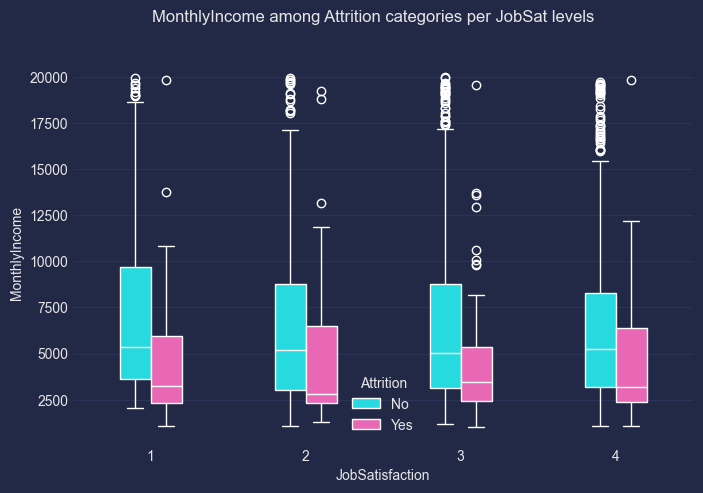

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ibmhr_df, x= 'JobSatisfaction' , y= 'MonthlyIncome',hue='Attrition', width=0.4, linecolor='white')
plt.suptitle("MonthlyIncome among Attrition categories per JobSat levels")
plt.show()

>Employees with low median incomes were likely to leave across all JobSat levels, 

This is something worth exploring.

### Q: Did employees who left had a low salary that was statistically significant?
#### Mann-Whitney U-test
- No difference in average monthlyIncome of employees who left vs those who stayed 
<br>$H_0: \mu_{yes} = \mu_{no}$
- Employees who stayed have higher average monthlyIncome compared to those who left
<br>$H_A: \mu_{yes} < \mu_{no}$
- assume significant value of $\alpha = 0.01$. This is the l

We have 1 numerical variable (monthly income) and two independent categories (2 employee groups - those who left vs those still at the org)

Ideally , it has to be either Independent sample t-test (parametric test) OR a Mann-Whitney U-test (non-parametric test).

NOTE: monthly income **is NOT normally distributed** in any of the 2 categories levels & hence the all assumptions required for parametric test are ruled out. 

So , a non-parametric hypothesis test -- **the Mann-Whitney U test**-- has to be applied. This test should help determine if there is indeed a statistically significant difference in monthly incomes of employees who left vs who staye in the org.

In [ ]:
# applying mann whitney u-test
# creating the two categories
grp1 = ibmhr_df[ibmhr_df['Attrition']=='Yes']['MonthlyIncome']
grp2 = ibmhr_df[ibmhr_df['Attrition']=='No']['MonthlyIncome']

stat, pvalue = stats.mannwhitneyu(grp1 , grp2 , alternative='less')
print(f"MWU stat = {stat} \nP-value = {pvalue}")

# comparing with significance value
pvalue < 0.01

MWU stat = 100620.5 
P-value = 1.4754154586444366e-14


np.True_

Thus we can reject the null hypothesis $H_0$ favour of $H_A$. 

This shows that, there is statistically significant evidence to suggest that the monthly income of employees who left the co. is less than those who stayed.

### Q: Does MonthlyIncome differ across Job Satisfaction levels?
#### Kruskal-Wallis test
A `groupby` will give better overview of average income $+$ attrition count per jobSat level.

- We're comparing differences of 1 numerical variable(monthly income) across 4 categorical variables (jobSat levels)
- Since monthly income is not normally distributed, a non-parametric test -- **the Kruskal-Wallis** -- needs to be applied

The hypotheses formed:
- Average monthly income is equal across all the JobSat levels<br>
$H_0: \mu_1 = \mu_2 = \mu_3 = \mu_4$
- At least one of the JobSat levels has a different average monthly income<br>
$H_A: \mu_i \neq \mu_j$ for at least one pair of JobSat level
- Assume $\alpha = 0.05$

The `pingouin` provides `pg.kruskal` method that is more easy to interpret.

In [ ]:
# reviewing employee count per jobSat level
attrtn_count= pd.DataFrame(ibmhr_df['JobSatisfaction'].value_counts().sort_index())
print(attrtn_count)

# grouping monthly income per jobSat level
# ibmhr_df.groupby(['JobSatisfaction','Attrition']).agg(
#     avg_income=('MonthlyIncome','mean'),
#     emp_count=('Attrition','count')
#     ).round(2)

ibmhr_df.groupby(['JobSatisfaction']).agg(avg_income=('MonthlyIncome','mean')).round(2)

                 count
JobSatisfaction       
1                  289
2                  280
3                  442
4                  459


,avg_income
JobSatisfaction,
1,6561.57
2,6527.33
3,6480.50
4,6472.73


In [ ]:
# applying kruskal-wallis test 
kw_result = pg.kruskal(data= ibmhr_df , dv='MonthlyIncome' , between='JobSatisfaction')
kw_result

,Source,ddof1,H,p_unc
Kruskal,JobSatisfaction,3,0.763488,0.858179


In [ ]:
# comparing with th significance level (0.05)
kw_result.loc['Kruskal','p_unc'] < 0.05

np.False_

>Hence there's sufficient evidence that Monthly Income is different between atleast 2 categories (JobSat levels)

**Post-hoc analysis:**<br>
It would've been about finding which exact pair(s) of JobSat level does a significant difference exist in monthly income. **Because the overall Kruskal-Wallis test showed absolutely zero global significance, the data does not provide sufficient evidence that the groups differ.** 

Hence, checking individual pairs with Dunn's test is also mathematically redundant.

>This also helps answer an important business question: _Should we increase salaries to improve Job Satisfaction?_

>And based on our analysis we can state that _Based on this dataset, employees with different Job Satisfaction levels do not exhibit statistically different salary distributions_ .

Above test doesn't prove salary has no influence on satisfaction.<br>
>It simply suggests that salary alone does not appear to explain the differences in Job Satisfaction in this dataset.

We can then direct our attention to other variables such as: WorkLifeBalance, EnvironmentSatisfaction, RelationshipSatisfaction, JobRole, Overtime, YearsSinceLastPromotion

Those might have a stronger association with Job Satisfaction than salary does.<br>
Looking into this aspect in the next section

## Studying Attrition by JobSat levels
### Is attrition associated with JobSatisfaction?
#### Chi-square test of independence
We're comparing a categorical variable (Attrition - Yes/ No) with another Categorial Variable (levels of JobSatisfaction - 1,2,3,4). Thus, we'll apply the **Chi-square Test of independence** to test for association between these categorical variables.

- $H_0:$ The 2 categories (attrition , jobSatisfaction) are independent<br>
- $H_A:$ The 2 categories (attrition , jobSatisfaction) *are NOT* independent
- Consider $\alpha=0.05$

**NOTE:** global proportions should carry over exactly into every single category, which applies to this case.



In [ ]:
# performing the chi-square test of independence
expected,observed,stats = pg.chi2_independence(data=ibmhr_df, x='Attrition', y='JobSatisfaction')

print(expected)
print("--------------------------------------")
print(stats)

JobSatisfaction           1           2           3           4
Attrition                                                      
No               242.406122  234.857143  370.738776  384.997959
Yes               46.593878   45.142857   71.261224   74.002041
--------------------------------------
                 test    lambda       chi2  dof      pval    cramer     power
0             pearson  1.000000  17.505077  3.0  0.000556  0.109125  0.953865
1        cressie-read  0.666667  17.422055  3.0  0.000579  0.108866  0.952934
2      log-likelihood  0.000000  17.356477  3.0  0.000597  0.108661  0.952186
3       freeman-tukey -0.500000  17.394341  3.0  0.000586  0.108779  0.952619
4  mod-log-likelihood -1.000000  17.507010  3.0  0.000556  0.109131  0.953886
5              neyman -2.000000  17.962352  3.0  0.000448  0.110541  0.958697


Thus we reject the null Hypothesis since all tests return a p-value < 0.05 (the significance level $\alpha$)

## Q: Does effect of Monthly Income on Attrition depend on JobSatis?
### Logistic regression with Interaction terms
Here, we're studying the combined effect of more than one predictor on a categorical (needs to be coverted to binary) variable.

We'll be using the `statsmodel` & the `pingouin` libraries.

- $H_0:$ relationship between MonthlyIncome & Attrition is the same across all Job Satisfaction levels (no interaction)
- $H_A:$ relationship between MonthlyIncome & Attrition depends on JobSat levels (i.e. an interaction exists)
- Consider a significance levle of 0.05

In [ ]:
# creating a compy of the dataset
ibmhr_df1 = ibmhr_df.copy()
# applying a binary map to Attrition column
ibmhr_df1['Attrition_numeric'] = ibmhr_df1['Attrition'].map({"Yes":1 , "No":0})

In [ ]:
# fit a logistic regression model with an interation term (JobSat level)
from statsmodels.formula.api import logit

model1 = logit("Attrition_numeric ~ MonthlyIncome * JobSatisfaction" , data=ibmhr_df1).fit()
print(model1.summary2())

Optimization terminated successfully.
         Current function value: 0.420635
         Iterations 7
                               Results: Logit
Model:                   Logit                Method:              MLE       
Dependent Variable:      Attrition_numeric    Pseudo R-squared:    0.048     
Date:                    2026-07-23 19:01     AIC:                 1244.6655 
No. Observations:        1470                 BIC:                 1265.8376 
Df Model:                3                    Log-Likelihood:      -618.33   
Df Residuals:            1466                 LL-Null:             -649.29   
Converged:               1.0000               LLR p-value:         2.2885e-13
No. Iterations:          7.0000               Scale:               1.0000    
-----------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------

- LLR p-value (2.2885e-13): This is the global model p-value. 
>Because it is practically zero, it confirms that your overall model is highly statistically significant compared to a baseline model with zero predictors.

- **Interaction effect:** The effect of Monthly Income on Attrition does NOT depend on Job Satisfaction - Because \(p = 0.6924\) is much greater than 0.05
>This means : Lower income increases attrition, and lower job satisfaction increases attrition, but these two factors operate completely independently of one another. They do not multiply or alter each other's effects.

- Main Effect1: MonthlyIncome (p = 0.0060) meaning it is Statistically Significant.
>Income has a significant negative relationship with attrition. As Monthly Income increases, the probability of an employee leaving decreases.

- Main Effect2: JobSatisfaction (p = 0.0110) meaning Statistically Significant.
>Job satisfaction has a significant negative relationship with attrition. As an employee's Job Satisfaction score increases, their probability of leaving decreases.

In [ ]:
# Use a two-way ANOVA to see how two categorical variables impact a numeric variable
anova_table = pg.anova(
    data=ibmhr_df,
    dv="MonthlyIncome",
    between=["Attrition", "JobSatisfaction"],
)
anova_table

,Source,SS,DF,MS,F,p_unc,np2
0,Attrition,8.492997e+08,1.0,8.492997e+08,39.174389,5.081899e-10,0.026096
1,JobSatisfaction,1.923133e+07,3.0,6.410443e+06,0.295685,8.285423e-01,0.000606
2,Attrition * JobSatisfaction,1.295295e+07,3.0,4.317651e+06,0.199154,8.969944e-01,0.000408
3,Residual,3.169612e+10,1462.0,2.167997e+07,NaN,NaN,NaN


- The Two-Way ANOVA reveals a significant main effect of Attrition on Monthly Income $(p < 0.001)$. 

- However, there is no significant main effect for Job Satisfaction $(p = 0.83)$ and average MonthlyIncome remains statistically identical across all satisfaction levels (1, 2, 3 & 4) when ignoring attrition. This mirrors the visualizations & single-variable Kruskal-Wallis test we ran earlier.

- Also, there's no significant interaction effect between Attrition and JobSatisfaction $(p \approx 0.90)$. 
>This indicates that while income varies significantly between staying and leaving employees, this gap is not influenced or altered by their level of job satisfaction.

## Studying Attrition by jobRoles

In [ ]:
ibmhr_df.groupby(['JobRole', 'Attrition'])['Attrition'].count()

JobRole                    Attrition
Healthcare Representative  No           122
                           Yes            9
Human Resources            No            40
                           Yes           12
Laboratory Technician      No           197
                           Yes           62
Manager                    No            97
                           Yes            5
Manufacturing Director     No           135
                           Yes           10
Research Director          No            78
                           Yes            2
Research Scientist         No           245
                           Yes           47
Sales Executive            No           269
                           Yes           57
Sales Representative       No            50
                           Yes           33
Name: Attrition, dtype: int64

In [ ]:
jb_list = ibmhr_df['JobRole'].unique().tolist()
jb_list.sort()
print(jb_list)

['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']


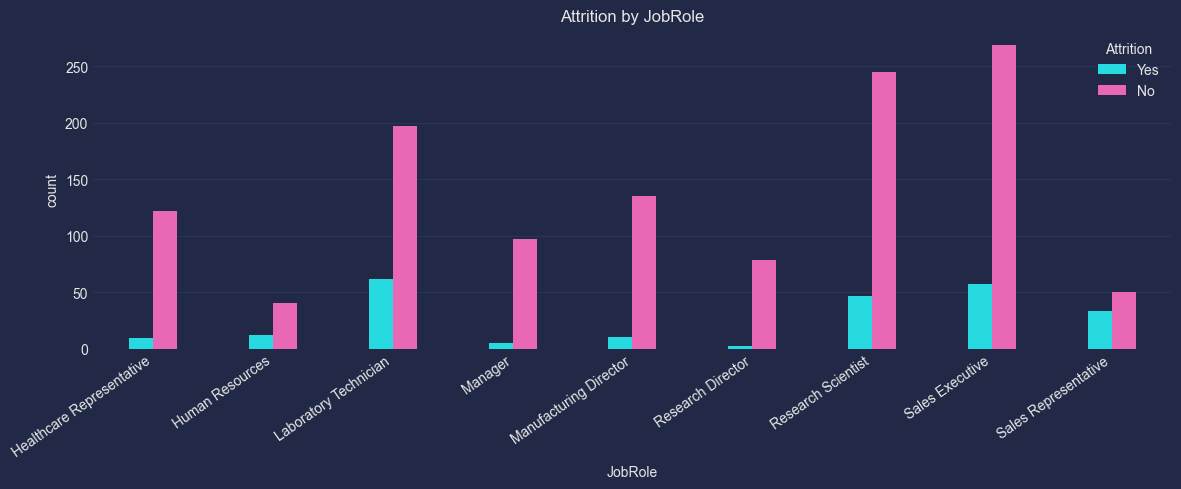

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=ibmhr_df, x='JobRole', hue='Attrition',  order=jb_list , width=0.4)
plt.title("Attrition by JobRole")
plt.xticks(ha='right', rotation=35)
plt.tight_layout()
plt.show()